<a href="https://colab.research.google.com/github/alvinputra2005/Final-Project-Al-Kautsar/blob/admin/Putu_Alvin_Mahendra_Putra_240535606978_TI_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Putu Alvin Mahendra Putra
NIM   : 240535606978
Kelas : C

In [ ]:
from random import seed, randint  # untuk random array
from time import process_time     # untuk menghitung durasi
import pandas as pd               # untuk tabel
import matplotlib.pyplot as plt   # untuk grafik
import numpy as np                # untuk fitting garis

### **Desain Analisis Algoritma T.Informatika UM**

In [ ]:
class MergeSort():
    def __init__(self):
        self.helper = []
        self.duration = 0

    def sort(self, a):
        start = process_time()
        a = self.mergesort(a)
        end = process_time()
        self.duration = end - start
        return a

    def print(self, comment, a):
        print(comment)
        print(a)

    def mergesort(self, a):
        m = len(a) // 2
        left = a[:m]
        right = a[m:]

        if len(left) > 1:
            left = self.mergesort(left)
        if len(right) > 1:
            right = self.mergesort(right)

        return self.merge(left, right)

    def merge(self, left, right):
        res = []
        while left and right:
            if left[-1] >= right[-1]:
                res.append(left.pop())
            else:
                res.append(right.pop())
        res.reverse()
        return (left or right) + res


In [ ]:
print("******Test MergeSort********")
mergeSort = MergeSort()
a = [49, 30, 1, 33, 21, 10]
mergeSort.print("Unsorted: ", a)
a = mergeSort.sort(a)
mergeSort.print("Sorted: ", a)

print("******Test MergeSort********")
N = 100
col1, col2 = [], []
seed(1234)

mergeSort = MergeSort()
while N < 10000:
    seq = [randint(0, 100) for i in range(N)]
    seq = mergeSort.sort(seq)
    print("%d %.4e" % (N, mergeSort.duration))
    col1.append(N)
    col2.append(mergeSort.duration)
    N *= 2

df = pd.DataFrame(list(zip(col1, col2)), columns=['N', 'Duration'])
print(df)


******Test MergeSort********
Unsorted: 
[49, 30, 1, 33, 21, 10]
Sorted: 
[1, 10, 21, 30, 33, 49]
******Test MergeSort********
100 1.2906e-04
200 2.6839e-04
400 1.7223e-03
800 1.2889e-03
1600 3.7463e-03
3200 5.7071e-03
6400 1.1991e-02
      N  Duration
0   100  0.000129
1   200  0.000268
2   400  0.001722
3   800  0.001289
4  1600  0.003746
5  3200  0.005707
6  6400  0.011991


<Figure size 400x200 with 0 Axes>

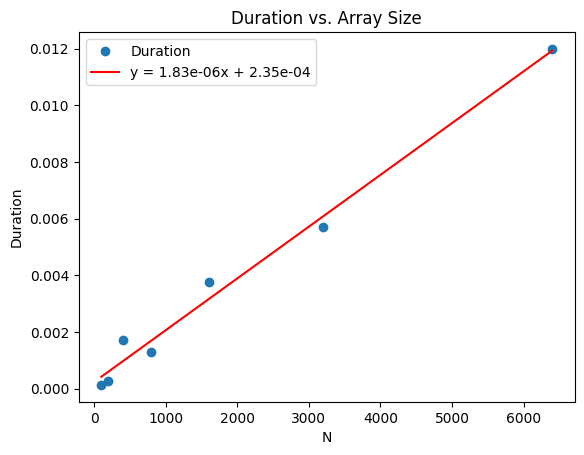

In [ ]:
fig = plt.figure(figsize=[4,2])
ax = df.plot(x='N', y='Duration', style='o', legend=True)

# Fit linear regression y = ax + b
x = df['N'].values
y = df['Duration'].values
a, b = np.polyfit(x, y, 1)   # linear fit
ax.plot(x, a*x + b, color='red', label=f'y = {a:.2e}x + {b:.2e}')
ax.legend()

ax.set_title('Duration vs. Array Size')
ax.set_xlabel('N')
ax.set_ylabel('Duration')
plt.show()


Rumus fungsi N vs Duration adalah y = 1.83e-06X + 2.35e-04